# H vector per founder — SEEDMIX_S1 Chr1, all v3qc-v2 configs

**Created 2026-05-18.** Direct h estimates for each of 231 founders, comparing every cactus_em config tested in this session. hapFIRE included as comparator. Cactus founders = blue ×, PG founders = orange ×. Red dashed line = 1/231 uniform expectation.

These h vectors are independent of the cn_var bug (h is estimated from cn_full k-mers, not cn_var). They reflect the effect of row-norm + K_f-α correction + filt2 directly.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
SCRATCH = ROOT / 'scratch'
HF_DIR = Path('/carnegie/nobackup/scratch/xwu/GrENE_net/hapFIRE_frequencies/seed_mix')

# Founder side membership
with open(ROOT / 'data/founder_split_cactus_pg.json') as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))

# Each config's h_per_chrom.npz; prefer new FIXED dir if present, fall back to legacy
CONFIGS = {
    'baseline (no rownorm)':         ['v3qc_v2_FIXED_baseline_chr1', 'seedmix_v3qc_v2_test'],
    'α=0 (rownorm, no K_f corr)':     ['v3qc_v2_FIXED_kfa0p0_chr1', 'seedmix_v3qc_v2_kfalpha0p0_chr1'],
    'α=1 (rownorm + h/K_f)':          ['v3qc_v2_FIXED_kfa1p0_chr1', 'seedmix_v3qc_v2_kfalpha1p0_chr1'],
    'α=2 (rownorm + h/K_f²)':         ['v3qc_v2_FIXED_kfa2p0_chr1', 'seedmix_v3qc_v2_kfalpha2p0_chr1'],
    'α=3 (rownorm + h/K_f³)':         ['v3qc_v2_FIXED_kfa3p0_chr1', 'seedmix_v3qc_v2_kfalpha3p0_chr1'],
    'α=5 (rownorm + h/K_f⁵)':         ['v3qc_v2_FIXED_kfa5p0_chr1', 'seedmix_v3qc_v2_kfalpha5p0_chr1'],
    'filt2 + rownorm':                ['v3qc_v2_FIXED_filt2rn_chr1', 'seedmix_v3qc_v2_filt2_rownorm_chr1'],
    'mixed-loose (>=1+1)':            ['v3qc_v2_mixedloose_chr1'],
    'mixed-strict (>=5+5)':           ['v3qc_v2_mixedstrict_chr1'],
    'mixed-conserv (>=10+10)':        ['v3qc_v2_mixedconserv_chr1'],
    'v3qc-v3 mixed-loose':            ['v3qc_v3_mixedloose_chr1'],
    'v3qc-v3 filt2 (drop ac=1 only)': ['v3qc_v3_filt2_chr1'],
}

# Subsample-experiment configs (2026-05-21): per-(founder, ac-stratum) median-target
# subsampling on raw v3qc_v3 (refilt2) and on filt2 v3qc_v3. h-only test, no AF projection.
# Format differs: these write `*.h_sweep.npz` with `h_proj_per_alpha[0]` for the α=0 entry.
SUBSAMP_PATHS = {
    'v3qc-v3 subsamp_raw (refilt2, seed42)':
        ROOT / 'scratch/subsample_h_test/subsampRaw_SEEDMIX_S1_chr1.h_sweep.npz',
    'v3qc-v3 subsamp_filt2 (seed42)':
        ROOT / 'scratch/subsample_h_test/subsampFilt2_SEEDMIX_S1_chr1.h_sweep.npz',
}
# Seed sensitivity (populated as SLURM job 63238 lands)
for s in [1, 7, 100]:
    SUBSAMP_PATHS[f'v3qc-v3 subsamp_raw seed{s}'] = (
        ROOT / f'scratch/subsample_h_test/subsampRaw_seed{s}_SEEDMIX_S1_chr1.h_sweep.npz'
    )

h_data = {}
for name, candidates in CONFIGS.items():
    for cand in candidates:
        p = SCRATCH / cand / 'SEEDMIX_S1.h_per_chrom.npz'
        if p.exists():
            z = np.load(p, allow_pickle=True)
            founders = list(np.asarray(z['founders']).astype(str))
            h_chr1 = z['Chr1']
            h_data[name] = (founders, h_chr1, cand)
            print(f'  ✓ {name}: {len(h_chr1)} founders ({cand})')
            break
    else:
        print(f'  ✗ MISSING: {name}')

# Load subsample h_sweep.npz files
for name, path in SUBSAMP_PATHS.items():
    if path.exists():
        z = np.load(path, allow_pickle=True)
        founders = list(np.asarray(z['founders']).astype(str))
        h = z['h_proj_per_alpha'][0]  # α=0 (no shape weighting; just subsampled cn)
        h_data[name] = (founders, h, str(path.parent.name))
        print(f'  ✓ {name}: {len(h)} founders ({path.parent.name})')
    else:
        print(f'  ⊘ pending: {name} ({path})')

# hapFIRE — load ecotype-level frequency for SEEDMIX_S1
hf_df = pd.read_csv(HF_DIR / 's1_ecotype_frequency.txt', sep='\t',
                    header=None, names=['ecotype', 'freq'])
hf_dict = dict(zip(hf_df['ecotype'].astype(str), hf_df['freq'].astype(float)))
print(f'hapFIRE ecotype freq loaded: {len(hf_dict)} entries')

  ✓ baseline (no rownorm): 231 founders (v3qc_v2_FIXED_baseline_chr1)
  ✓ α=0 (rownorm, no K_f corr): 231 founders (v3qc_v2_FIXED_kfa0p0_chr1)
  ✓ α=1 (rownorm + h/K_f): 231 founders (v3qc_v2_FIXED_kfa1p0_chr1)
  ✓ α=2 (rownorm + h/K_f²): 231 founders (v3qc_v2_FIXED_kfa2p0_chr1)
  ✓ α=3 (rownorm + h/K_f³): 231 founders (v3qc_v2_FIXED_kfa3p0_chr1)
  ✓ α=5 (rownorm + h/K_f⁵): 231 founders (v3qc_v2_FIXED_kfa5p0_chr1)
  ✓ filt2 + rownorm: 231 founders (v3qc_v2_FIXED_filt2rn_chr1)
  ✓ mixed-loose (>=1+1): 231 founders (v3qc_v2_mixedloose_chr1)
  ✓ mixed-strict (>=5+5): 231 founders (v3qc_v2_mixedstrict_chr1)
  ✓ mixed-conserv (>=10+10): 231 founders (v3qc_v2_mixedconserv_chr1)
  ✓ v3qc-v3 mixed-loose: 231 founders (v3qc_v3_mixedloose_chr1)
  ✓ v3qc-v3 filt2 (drop ac=1 only): 231 founders (v3qc_v3_filt2_chr1)
  ✓ v3qc-v3 subsamp_raw (refilt2, seed42): 231 founders (subsample_h_test)
  ✓ v3qc-v3 subsamp_filt2 (seed42): 231 founders (subsample_h_test)
  ⊘ pending: v3qc-v3 subsamp_raw seed1 (/c

In [2]:
# Use the founder order from the first available config as canonical
canonical_founders = next(iter(h_data.values()))[0]
F = len(canonical_founders)
UNIFORM = 1.0 / F
print(f'F={F}, uniform expectation = 1/{F} = {UNIFORM:.5f}')

is_cactus = np.array([f in cactus_set for f in canonical_founders])
is_pg     = np.array([f in pg_set for f in canonical_founders])
print(f'cactus={is_cactus.sum()}, PG={is_pg.sum()}')

# hapFIRE h aligned to canonical order
h_hapfire = np.array([hf_dict.get(f, np.nan) for f in canonical_founders])
n_matched = np.isfinite(h_hapfire).sum()
print(f'hapFIRE founders matched to canonical: {n_matched}/{F}')

# Sort founders by hapFIRE h, ascending (founders w/o hapFIRE go to the end).
# With this x-axis, a perfect estimator would trace a monotonic curve, and
# under/over-estimates show as scatter below/above the hapFIRE comparator.
order = np.argsort(np.where(np.isfinite(h_hapfire), h_hapfire, np.inf))
x = np.arange(F)
founders_sorted = np.array(canonical_founders)[order]
is_cactus_sorted = is_cactus[order]
is_pg_sorted     = is_pg[order]
h_hapfire_sorted = h_hapfire[order]

F=231, uniform expectation = 1/231 = 0.00433
cactus=80, PG=151
hapFIRE founders matched to canonical: 231/231


## Per-config h-vector panels

Each panel: founders sorted by hapFIRE h (ascending) on x-axis, h on y-axis. Cactus founders blue, PG orange. hapFIRE shown as gray dots for context (not truth). Truth = 1/231 (red dashed) since SEEDMIX is designed equal-mix. Cactus founders blue, PG orange. Black bar = side median, red dashed = 1/231 uniform.

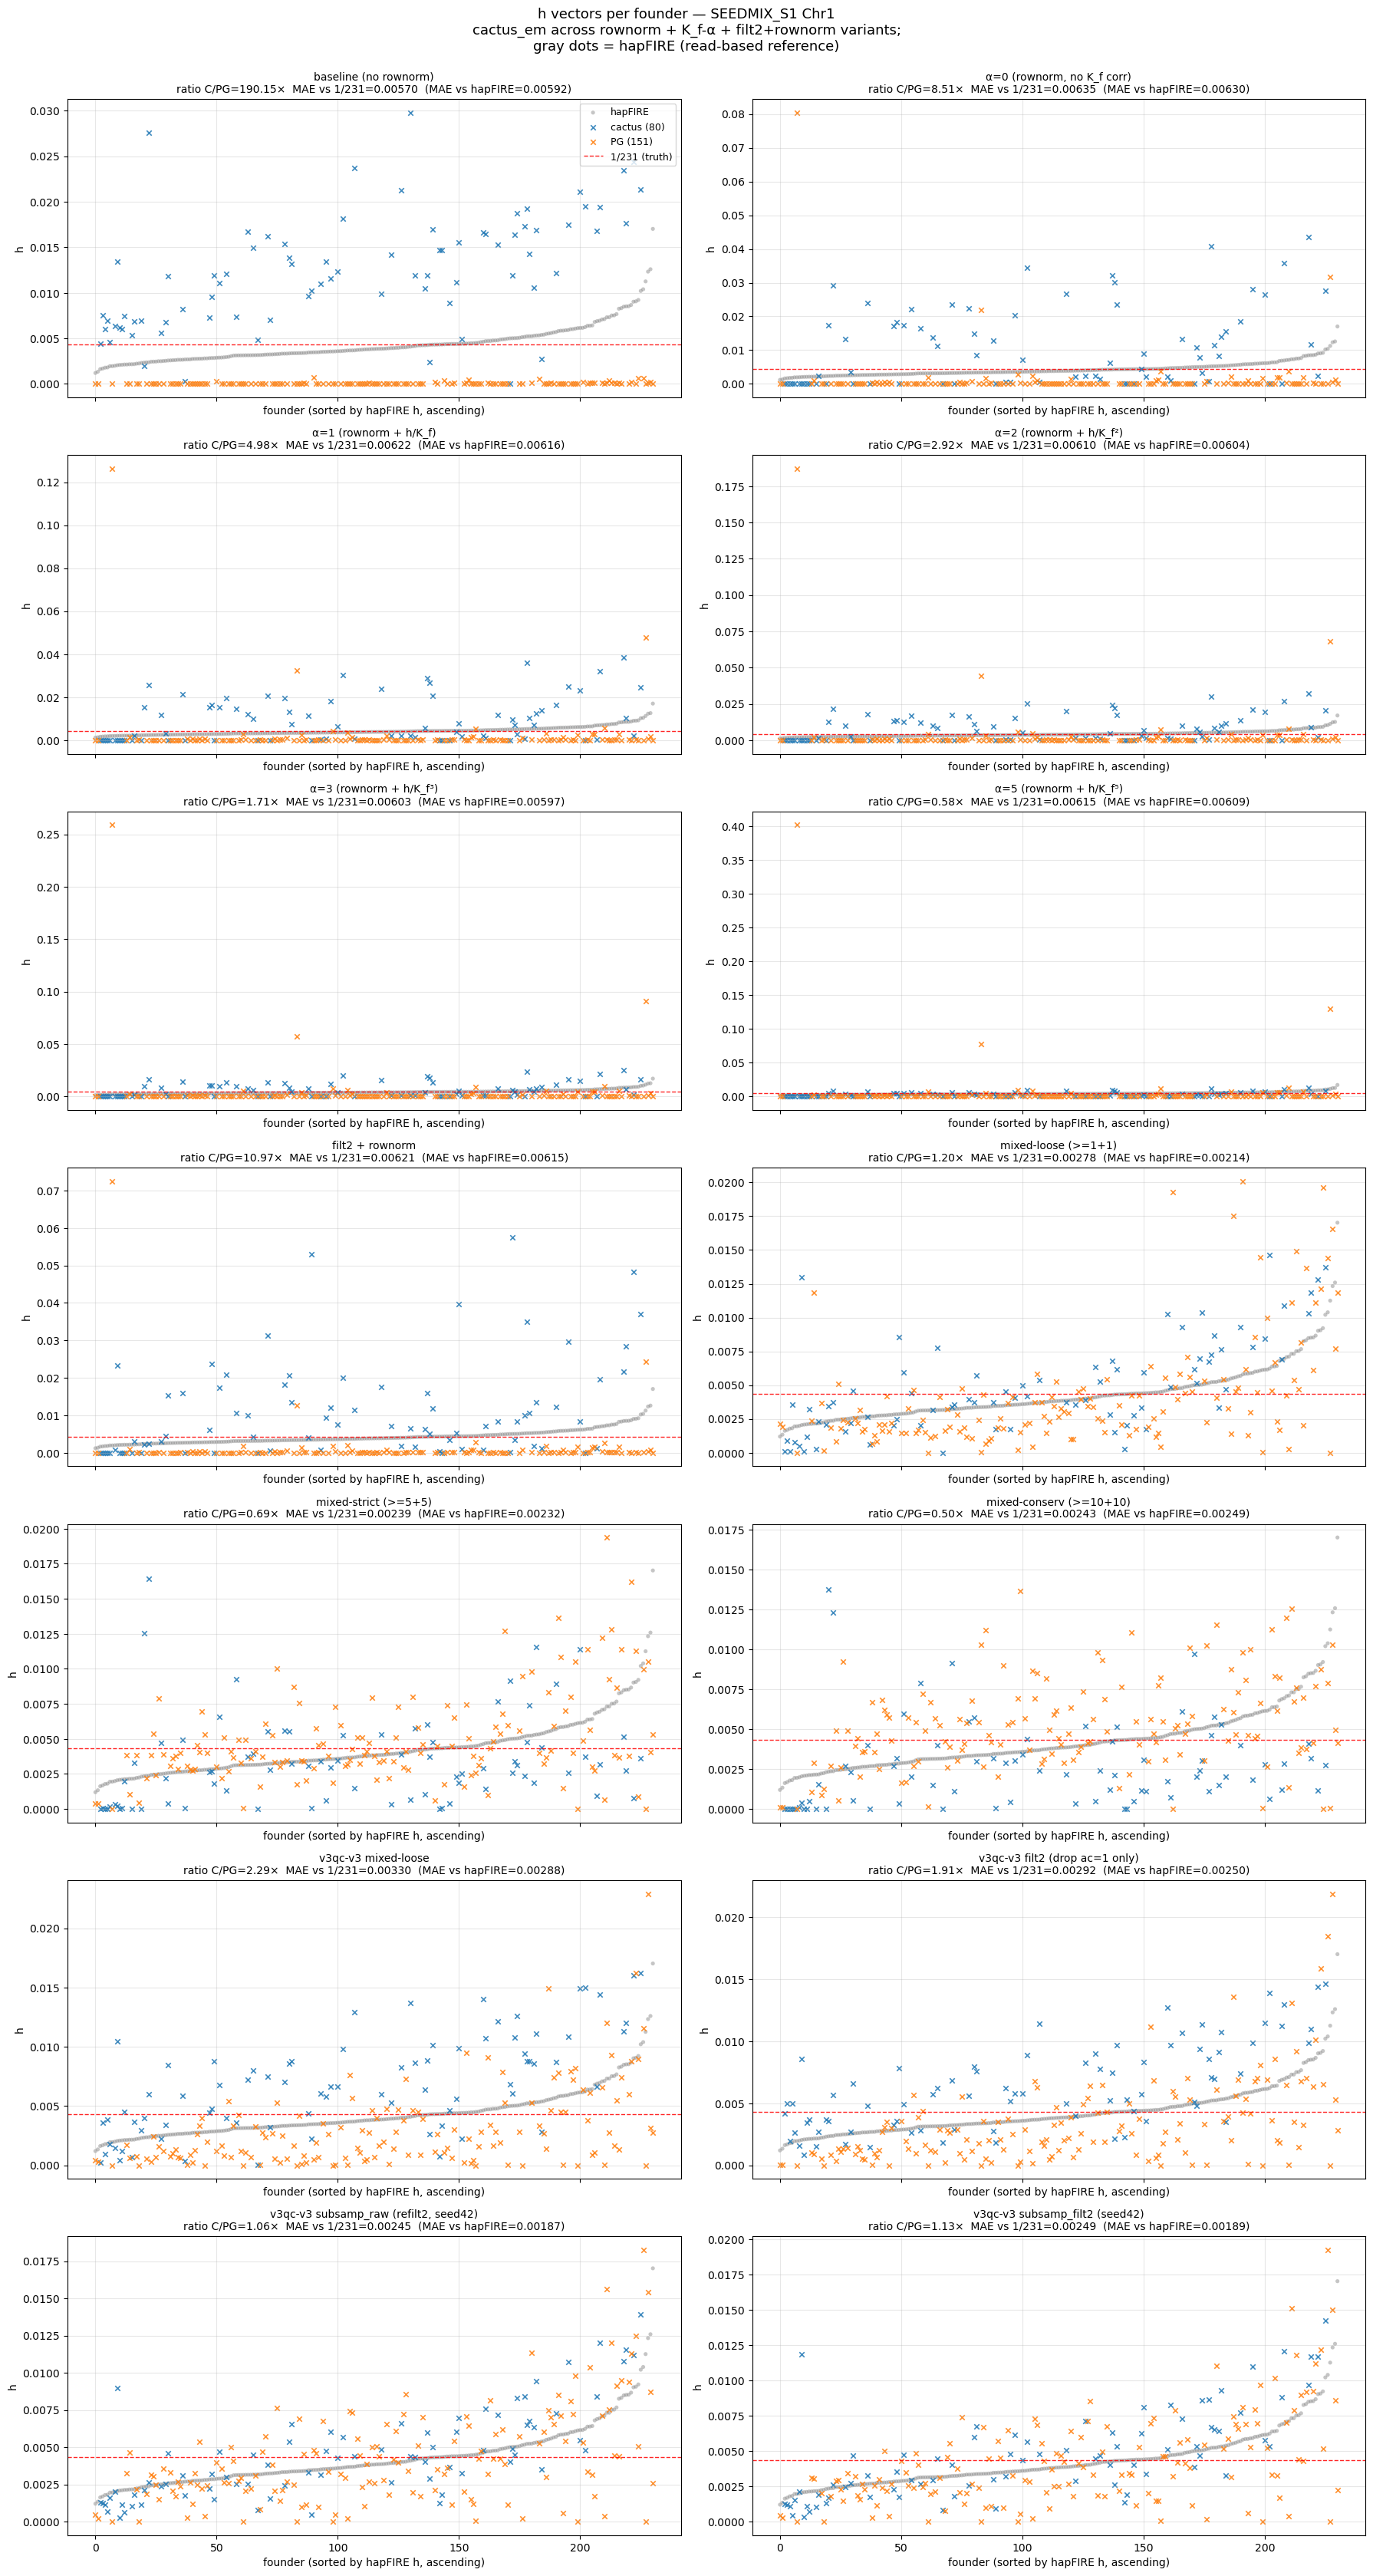

In [3]:
CACT_BLUE = '#1f77b4'
PG_ORANGE = '#ff7f0e'
GRAY = '#808080'

def plot_h_panel(ax, h, name, ref_method='hapFIRE'):
    # x-axis = founder index, sorted by hapFIRE h (just visual continuity).
    # Truth = 1/231 uniform (red dashed). hapFIRE shown as comparator (gray dots).
    h_sorted = h[order]
    # hapFIRE comparator as dots
    ax.scatter(x, h_hapfire_sorted, c=GRAY, marker='o', s=14, alpha=0.45,
               edgecolor='none', label='hapFIRE')
    # method h as × colored by side
    ax.scatter(x[is_cactus_sorted], h_sorted[is_cactus_sorted],
               c=CACT_BLUE, marker='x', s=22, lw=1.2, alpha=0.85,
               label=f'cactus ({is_cactus_sorted.sum()})')
    ax.scatter(x[is_pg_sorted], h_sorted[is_pg_sorted],
               c=PG_ORANGE, marker='x', s=22, lw=1.2, alpha=0.85,
               label=f'PG ({is_pg_sorted.sum()})')
    # truth = 1/231
    ax.axhline(UNIFORM, color='red', ls='--', lw=1.0, alpha=0.85, label='1/231 (truth)')
    # Metrics computed vs 1/231 (the actual expectation), not vs hapFIRE
    pf_c = h_sorted[is_cactus_sorted].mean()
    pf_p = h_sorted[is_pg_sorted].mean()
    bias = pf_c / pf_p if pf_p > 0 else np.inf
    mae_uniform = np.mean(np.abs(h - UNIFORM))
    # hapFIRE distance shown for context — not the truth, but the only other measurement we have
    finite = np.isfinite(h_hapfire)
    mae_hf = np.mean(np.abs(h[finite] - h_hapfire[finite]))
    ax.set_title(f'{name}\nratio C/PG={bias:.2f}×  MAE vs 1/231={mae_uniform:.5f}  '
                 f'(MAE vs hapFIRE={mae_hf:.5f})', fontsize=10)
    ax.set_xlabel('founder (sorted by hapFIRE h, ascending)')
    ax.set_ylabel('h')
    ax.grid(alpha=0.3)

n_configs = len(h_data)
ncols = 2
nrows = (n_configs + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows), sharex=True, sharey=False)
axes = np.atleast_2d(axes).flatten()

for i, (name, (founders, h, src)) in enumerate(h_data.items()):
    # Verify founder alignment
    assert founders == canonical_founders, f'founder order mismatch for {name}'
    plot_h_panel(axes[i], h, name)
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

# Hide unused panels
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('h vectors per founder — SEEDMIX_S1 Chr1\n'
             'cactus_em across rownorm + K_f-α + filt2+rownorm variants;\n'
             'gray dots = hapFIRE (read-based reference)',
             fontsize=13, y=0.998)
plt.tight_layout()
plt.savefig('plots/H_VECTOR_COMPARISON_v3qc_v2_S1_chr1.png', dpi=130, bbox_inches='tight')
plt.show()

## Side-by-side comparison: one chart, all configs overlaid

One panel, dot color encodes config. Helps see how h shifts as α increases.

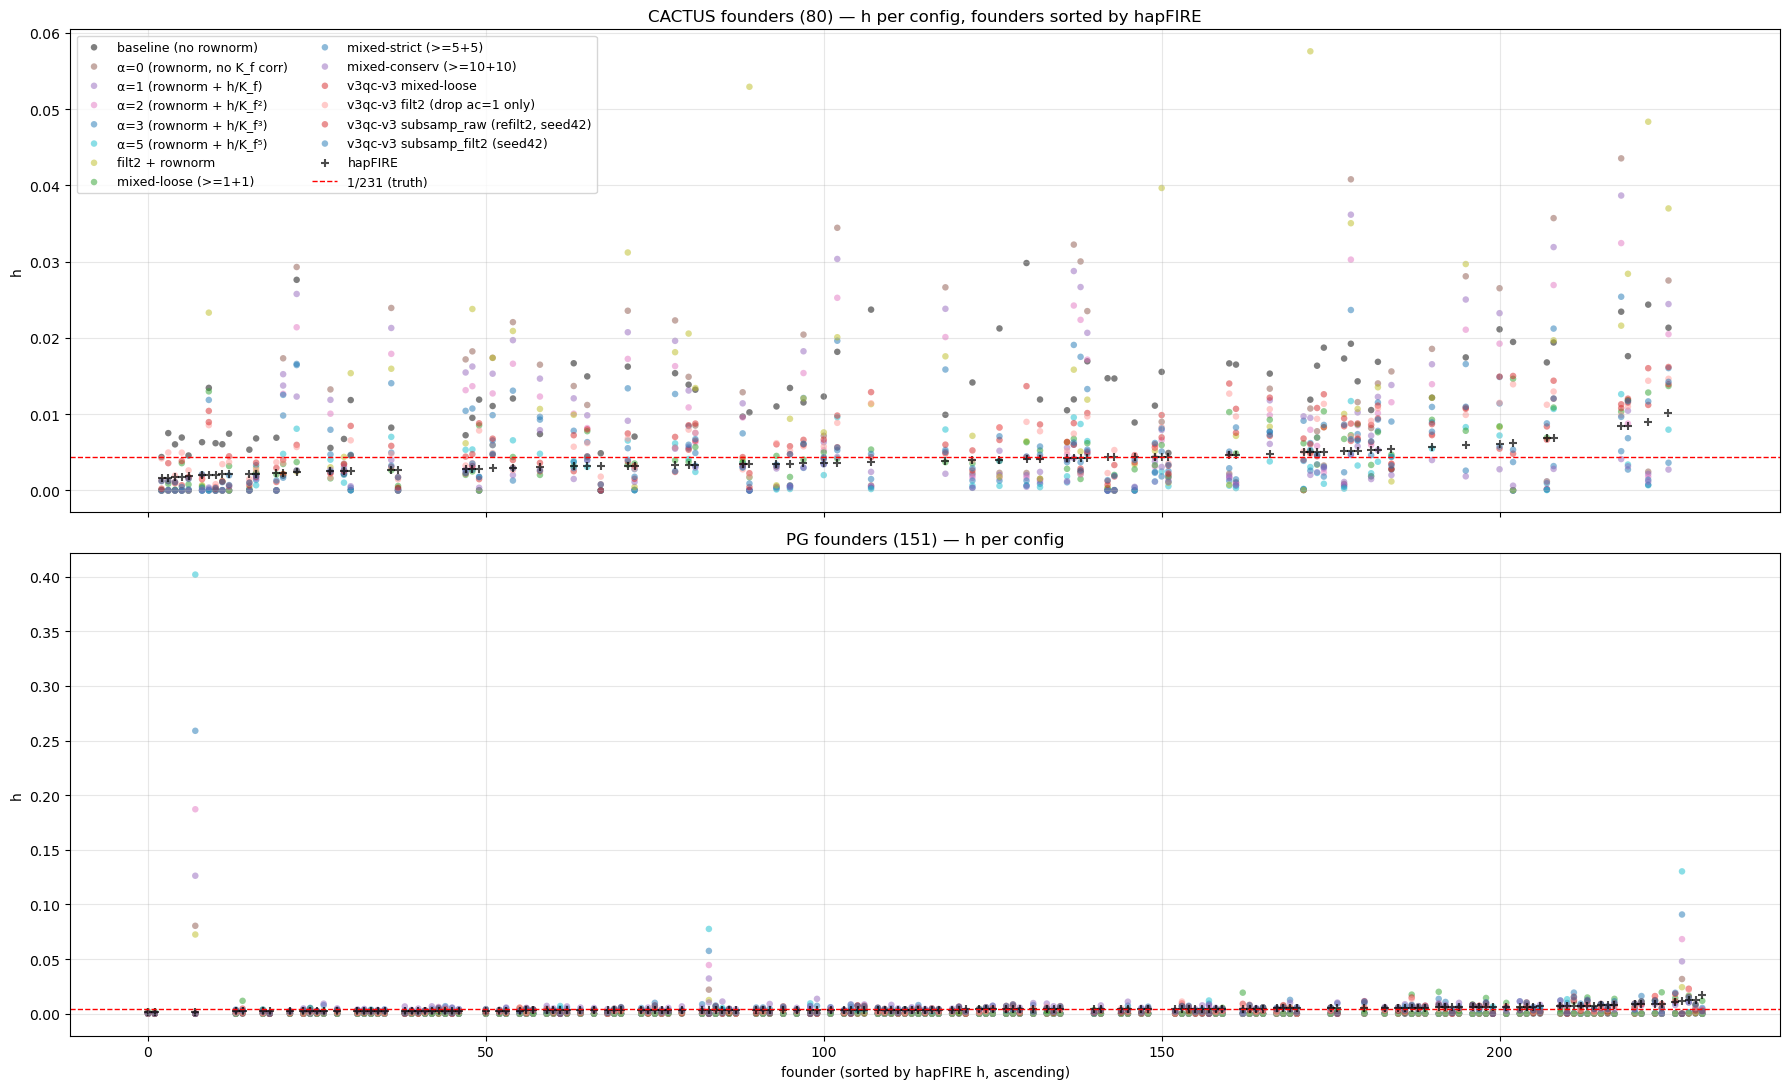

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=True)

config_colors = {
    'baseline (no rownorm)':       '#000000',
    'α=0 (rownorm, no K_f corr)':   '#8c564b',
    'α=1 (rownorm + h/K_f)':        '#9467bd',
    'α=2 (rownorm + h/K_f²)':       '#e377c2',
    'α=3 (rownorm + h/K_f³)':       '#1f77b4',
    'α=5 (rownorm + h/K_f⁵)':       '#17becf',
    'filt2 + rownorm':              '#bcbd22',
    'mixed-loose (>=1+1)':           '#2ca02c',
    'mixed-strict (>=5+5)':          '#1f77b4',
    'mixed-conserv (>=10+10)':       '#9467bd',
    'v3qc-v3 mixed-loose':           '#d62728',
    'v3qc-v3 filt2 (drop ac=1 only)':'#ff9896',
    # subsample (2026-05-21)
    'v3qc-v3 subsamp_raw (refilt2, seed42)': '#d62728',
    'v3qc-v3 subsamp_filt2 (seed42)':         '#1f77b4',
    'v3qc-v3 subsamp_raw seed1':              '#9467bd',
    'v3qc-v3 subsamp_raw seed7':              '#2ca02c',
    'v3qc-v3 subsamp_raw seed100':            '#17becf',
}

# Top: cactus founders only, sorted by hapFIRE h
ax = axes[0]
for name, (founders, h, src) in h_data.items():
    h_sorted = h[order]
    ax.scatter(x[is_cactus_sorted], h_sorted[is_cactus_sorted],
               c=config_colors.get(name, GRAY), marker='o', s=22, alpha=0.5,
               edgecolor='none', label=name)
ax.scatter(x[is_cactus_sorted], h_hapfire_sorted[is_cactus_sorted],
           c='black', marker='+', s=40, alpha=0.7, label='hapFIRE')
ax.axhline(UNIFORM, color='red', ls='--', lw=1, label='1/231 (truth)')
ax.set_ylabel('h')
ax.set_title(f'CACTUS founders ({is_cactus_sorted.sum()}) — h per config, founders sorted by hapFIRE')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(alpha=0.3)

# Bottom: PG founders only
ax = axes[1]
for name, (founders, h, src) in h_data.items():
    h_sorted = h[order]
    ax.scatter(x[is_pg_sorted], h_sorted[is_pg_sorted],
               c=config_colors.get(name, GRAY), marker='o', s=22, alpha=0.5,
               edgecolor='none', label=name)
ax.scatter(x[is_pg_sorted], h_hapfire_sorted[is_pg_sorted],
           c='black', marker='+', s=40, alpha=0.7, label='hapFIRE')
ax.axhline(UNIFORM, color='red', ls='--', lw=1, label='1/231 (truth)')
ax.set_xlabel('founder (sorted by hapFIRE h, ascending)')
ax.set_ylabel('h')
ax.set_title(f'PG founders ({is_pg_sorted.sum()}) — h per config')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/H_VECTOR_COMPARISON_v3qc_v2_S1_chr1_overlay.png', dpi=130, bbox_inches='tight')
plt.show()

## Side-aggregated summary

In [5]:
rows = []
# hapFIRE row
h_c = h_hapfire[is_cactus]
h_c = h_c[np.isfinite(h_c)]
h_p = h_hapfire[is_pg]
h_p = h_p[np.isfinite(h_p)]
if len(h_c) and len(h_p):
    rows.append({
        'config': 'hapFIRE',
        'sum_h_C': h_c.sum(),
        'sum_h_PG': h_p.sum(),
        'mean_h_C': h_c.mean(),
        'mean_h_PG': h_p.mean(),
        'h_bias_per_founder': h_c.mean() / h_p.mean() if h_p.mean() > 0 else np.inf,
        'std_h_C': h_c.std(),
        'std_h_PG': h_p.std(),
    })

for name, (founders, h, src) in h_data.items():
    h_c = h[is_cactus]; h_p = h[is_pg]
    rows.append({
        'config': name,
        'sum_h_C': h_c.sum(),
        'sum_h_PG': h_p.sum(),
        'mean_h_C': h_c.mean(),
        'mean_h_PG': h_p.mean(),
        'h_bias_per_founder': h_c.mean() / h_p.mean() if h_p.mean() > 0 else np.inf,
        'std_h_C': h_c.std(),
        'std_h_PG': h_p.std(),
    })
summary = pd.DataFrame(rows)
for c in ['sum_h_C', 'sum_h_PG', 'mean_h_C', 'mean_h_PG', 'std_h_C', 'std_h_PG']:
    summary[c] = summary[c].map(lambda v: f'{v:.5f}')
summary['h_bias_per_founder'] = summary['h_bias_per_founder'].map(lambda v: f'{v:.2f}×')
print(summary.to_string(index=False))

                               config sum_h_C sum_h_PG mean_h_C mean_h_PG h_bias_per_founder std_h_C std_h_PG
                              hapFIRE 0.31862  0.68138  0.00398   0.00451              0.88× 0.00172  0.00224
                baseline (no rownorm) 0.99017  0.00983  0.01238   0.00007            190.15× 0.00620  0.00012
           α=0 (rownorm, no K_f corr) 0.81842  0.18158  0.01023   0.00120              8.51× 0.01155  0.00720
                α=1 (rownorm + h/K_f) 0.72535  0.27465  0.00907   0.00182              4.98× 0.01025  0.01120
               α=2 (rownorm + h/K_f²) 0.60717  0.39283  0.00759   0.00260              2.92× 0.00859  0.01647
               α=3 (rownorm + h/K_f³) 0.47463  0.52537  0.00593   0.00348              1.71× 0.00672  0.02262
               α=5 (rownorm + h/K_f⁵) 0.23523  0.76477  0.00294   0.00506              0.58× 0.00334  0.03467
                      filt2 + rownorm 0.85320  0.14680  0.01066   0.00097             10.97× 0.01284  0.00626
          

## Per-founder agreement: each config's h vs hapFIRE h

Does mixed-loose just have the same SIDE-AVERAGE as hapFIRE, or does it actually agree with hapFIRE on which individual founders are over/under-represented in the pool?

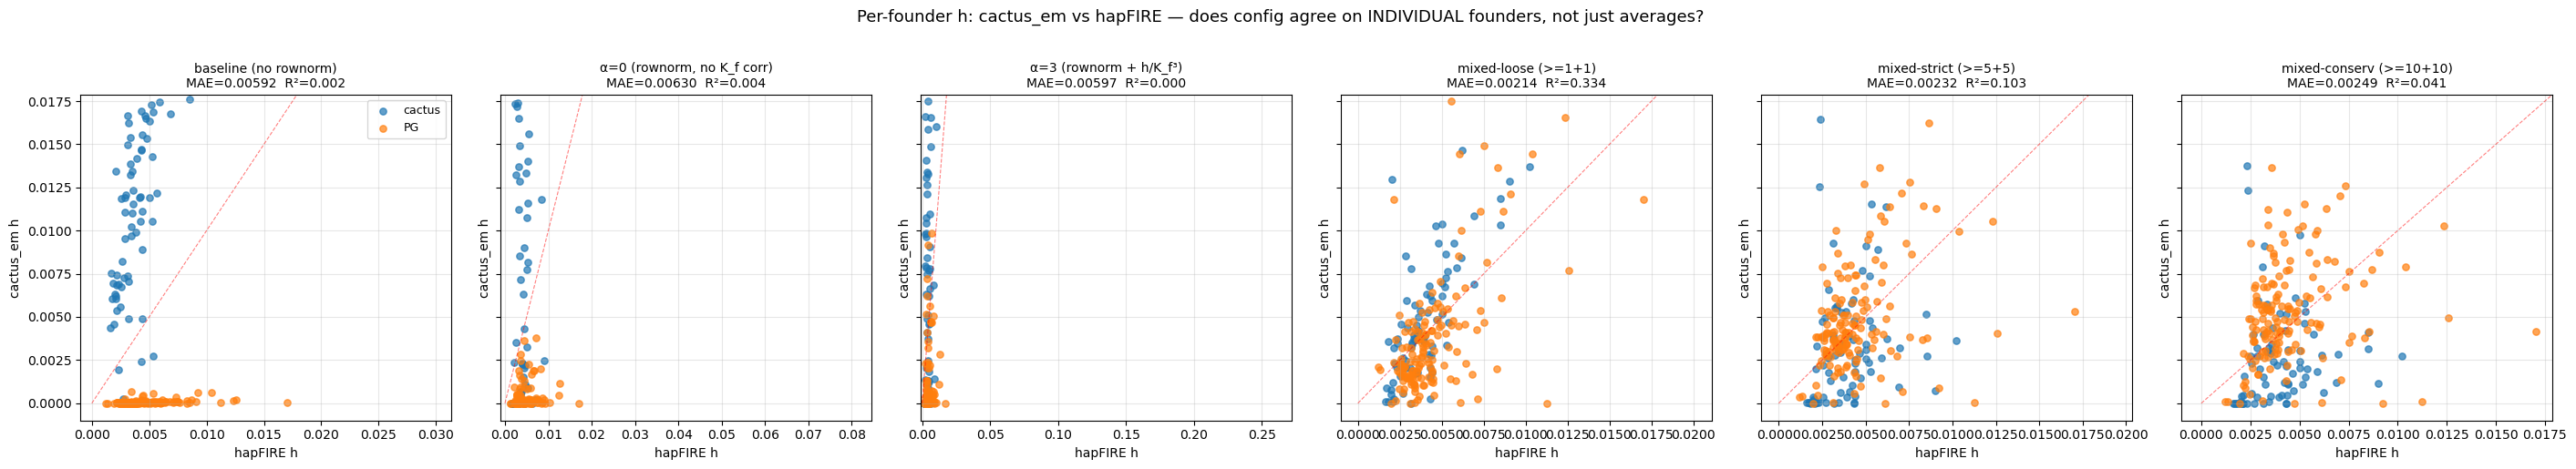

In [6]:
from matplotlib.colors import LogNorm
configs_to_compare = ['baseline (no rownorm)', 'rownorm only (α=0)', 'α=3 (rownorm + h/K_f³)' if 'α=3 (rownorm + h/K_f³)' in h_data else 'α=3 (rownorm + h/K_f³)',
                      'mixed-loose (>=1+1)', 'mixed-strict (>=5+5)', 'mixed-conserv (>=10+10)']
configs_to_compare = [k for k in h_data.keys() if k in {'baseline (no rownorm)', 'α=0 (rownorm, no K_f corr)',
                                                          'α=3 (rownorm + h/K_f³)', 'mixed-loose (>=1+1)',
                                                          'mixed-strict (>=5+5)', 'mixed-conserv (>=10+10)'}]
n = len(configs_to_compare)
fig, axes = plt.subplots(1, n, figsize=(4.7*n, 5), sharey=True)
if n == 1: axes = [axes]
for ax, name in zip(axes, configs_to_compare):
    _, h, _ = h_data[name]
    # Per-founder scatter: hapFIRE vs cactus_em h, colored by side
    finite = np.isfinite(h_hapfire) & np.isfinite(h)
    ax.scatter(h_hapfire[finite & is_cactus], h[finite & is_cactus],
               c='#1f77b4', alpha=0.7, s=28, label='cactus')
    ax.scatter(h_hapfire[finite & is_pg], h[finite & is_pg],
               c='#ff7f0e', alpha=0.7, s=28, label='PG')
    lim = max(h[finite].max(), h_hapfire[finite].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=0.8, alpha=0.5)
    ax.set_xlim(-0.001, lim); ax.set_ylim(-0.001, lim)
    ax.set_xlabel('hapFIRE h'); ax.set_ylabel('cactus_em h')
    # Per-founder MAE
    mae = np.mean(np.abs(h[finite] - h_hapfire[finite]))
    r2 = np.corrcoef(h[finite], h_hapfire[finite])[0,1]**2
    ax.set_title(f'{name}\nMAE={mae:.5f}  R²={r2:.3f}', fontsize=10)
    if ax is axes[0]: ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('Per-founder h: cactus_em vs hapFIRE — does config agree on INDIVIDUAL founders, not just averages?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/H_VECTOR_COMPARISON_v3qc_v2_perfounder.png', dpi=130, bbox_inches='tight')
plt.show()